# Analisis de negocio sobre `gold`

Consolida las preguntas de negocio ya validadas en SQL (notebooks de `gold/`), esta vez con visualizacion y hallazgos accionables. Cubre las 3 estrellas (academica, facturacion, comercial) mas el cruce cross-domain estudiante<->cliente.

Cada seccion sigue el mismo patron: query -> grafico -> hallazgo en texto, con los numeros reales de la corrida (no estimados).

In [ ]:
import sys
sys.path.append("/home/jovyan/work/src")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from utils.db import get_engine

engine = get_engine()

# Paleta validada (colorblind-safe, orden fijo) -- ver dataviz skill / docs/decisiones.md
CATEGORICAL = ["#2a78d6", "#008300", "#e87ba4", "#eda100", "#1baf7a", "#eb6834", "#4a3aa7", "#e34948"]
BLUE, GREEN, MAGENTA, YELLOW, AQUA, ORANGE, VIOLET, RED = CATEGORICAL
INK, MUTED, GRID, SURFACE = "#0b0b0b", "#898781", "#e1e0d9", "#fcfcfb"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK, "text.color": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "font.family": "sans-serif", "font.size": 11,
})

def bar_labels(ax, fmt="{:.1f}"):
    for c in ax.containers:
        ax.bar_label(c, fmt=fmt, color=INK, fontsize=9, padding=3)

## 1. Academico

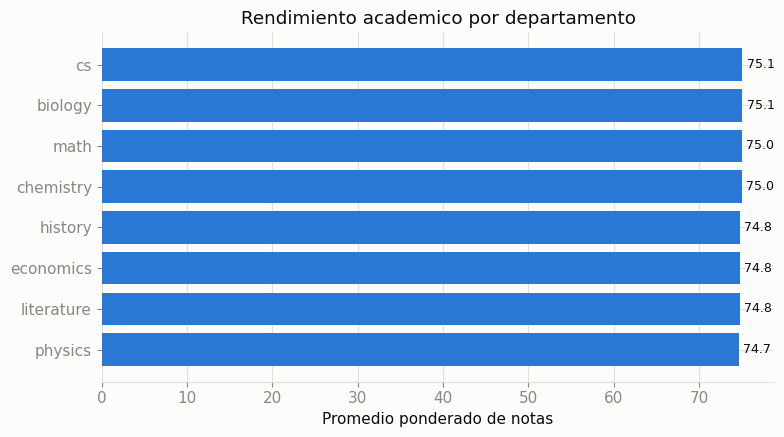

,department,inscripciones,promedio,pct_aprobados
0,cs,3662,75.1,95.7
1,biology,3411,75.1,95.9
2,math,1765,75.0,95.5
3,chemistry,2505,75.0,95.3
4,history,2378,74.8,95.5
5,economics,2612,74.8,95.6
6,literature,2547,74.8,94.9
7,physics,3906,74.7,95.0


In [ ]:
perf_dept = pd.read_sql("SELECT * FROM gold.vw_academic_performance_by_department ORDER BY promedio DESC", engine)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(perf_dept["department"], perf_dept["promedio"], color=BLUE)
ax.invert_yaxis()
ax.set_xlabel("Promedio ponderado de notas")
ax.set_title("Rendimiento academico por departamento")
bar_labels(ax)
plt.tight_layout()
plt.show()
perf_dept

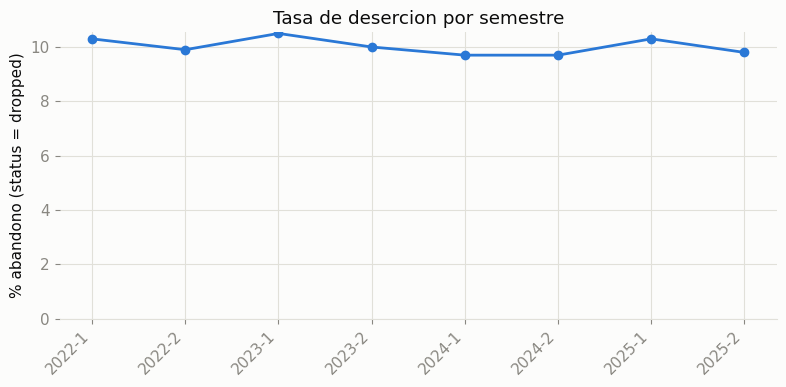

,year,half,code,inscripciones,pct_abandono
0,2022,1,2022-1,3164,10.3
1,2022,2,2022-2,3199,9.9
2,2023,1,2023-1,3143,10.5
3,2023,2,2023-2,3014,10.0
4,2024,1,2024-1,3076,9.7
5,2024,2,2024-2,3108,9.7
6,2025,1,2025-1,3110,10.3
7,2025,2,2025-2,3186,9.8


In [ ]:
dropout_sem = pd.read_sql("""
    SELECT s.year, s.half, s.code,
           count(*) AS inscripciones,
           round(100.0 * count(*) FILTER (WHERE f.status = 'dropped') / count(*), 1) AS pct_abandono
    FROM gold.fact_enrollment f JOIN gold.dim_semester s ON s.semester_id = f.semester_id
    GROUP BY s.year, s.half, s.code ORDER BY s.year, s.half
""", engine)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(dropout_sem["code"], dropout_sem["pct_abandono"], marker="o", color=BLUE, linewidth=2)
ax.set_ylabel("% abandono (status = dropped)")
ax.set_title("Tasa de desercion por semestre")
ax.set_ylim(bottom=0)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
dropout_sem

**Hallazgo:** el rendimiento academico es parejo entre departamentos (74.7-75.1 de promedio, 94.9-95.9% de aprobacion en todos) -- no hay un departamento problematico que amerite intervencion puntual.

La tasa de abandono por semestre es **estable en el tiempo** (9.7%-10.5% en los 8 semestres, sin tendencia creciente ni decreciente) -- no hay una alerta de desercion en aumento, es un problema estructural de ~10% constante, no un fenomeno que este empeorando.

## 2. Facturacion

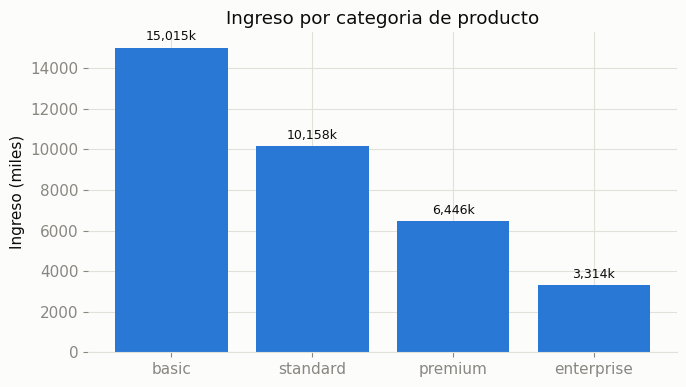

,category,ingreso
0,basic,15014847.32
1,standard,10157638.58
2,premium,6445684.88
3,enterprise,3313635.53


In [ ]:
revenue_cat = pd.read_sql("""
    SELECT p.category, sum(ii.line_total) AS ingreso
    FROM gold.fact_invoice_item ii JOIN gold.dim_product p ON p.product_id = ii.product_id
    GROUP BY p.category ORDER BY ingreso DESC
""", engine)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(revenue_cat["category"], revenue_cat["ingreso"] / 1000, color=BLUE)
ax.set_ylabel("Ingreso (miles)")
ax.set_title("Ingreso por categoria de producto")
bar_labels(ax, fmt="{:,.0f}k")
plt.tight_layout()
plt.show()
revenue_cat

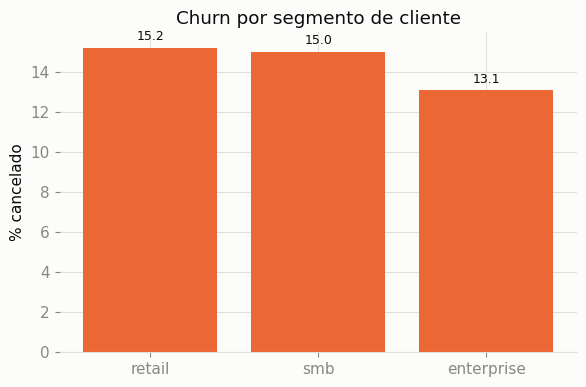

,segment,suscripciones,canceladas,churn_rate_pct
0,retail,10528,1595,15.2
1,smb,3301,494,15.0
2,enterprise,1171,153,13.1


In [ ]:
churn_seg = pd.read_sql("SELECT * FROM gold.vw_churn_by_segment ORDER BY churn_rate_pct DESC", engine)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(churn_seg["segment"], churn_seg["churn_rate_pct"], color=ORANGE)
ax.set_ylabel("% cancelado")
ax.set_title("Churn por segmento de cliente")
bar_labels(ax)
plt.tight_layout()
plt.show()
churn_seg

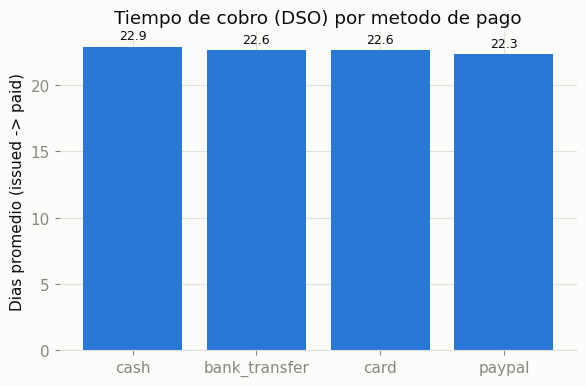

,method,pagos,dias_promedio_pago
0,cash,3969,22.9
1,bank_transfer,24054,22.6
2,card,43990,22.6
3,paypal,7987,22.3


In [ ]:
dso_method = pd.read_sql("SELECT * FROM gold.vw_dso_by_payment_method ORDER BY dias_promedio_pago DESC", engine)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(dso_method["method"], dso_method["dias_promedio_pago"], color=BLUE)
ax.set_ylabel("Dias promedio (issued -> paid)")
ax.set_title("Tiempo de cobro (DSO) por metodo de pago")
bar_labels(ax)
plt.tight_layout()
plt.show()
dso_method

**Hallazgo:** el churn de `retail` (15.2%) y `smb` (15.0%) es mayor que `enterprise` (13.1%) -- consistente con lo esperado (cuentas grandes son mas dificiles de perder por switching cost), aunque la diferencia es moderada (~2 puntos), no dramatica.

El DSO por metodo de pago es **casi identico entre los 4 metodos** (22.3-22.9 dias) -- no hay un metodo de cobro claramente mas lento que amerite accion. Este es un hallazgo negativo util: descarta una hipotesis (que el metodo de pago afecta la velocidad de cobro) en vez de confirmarla.

## 3. Comercial

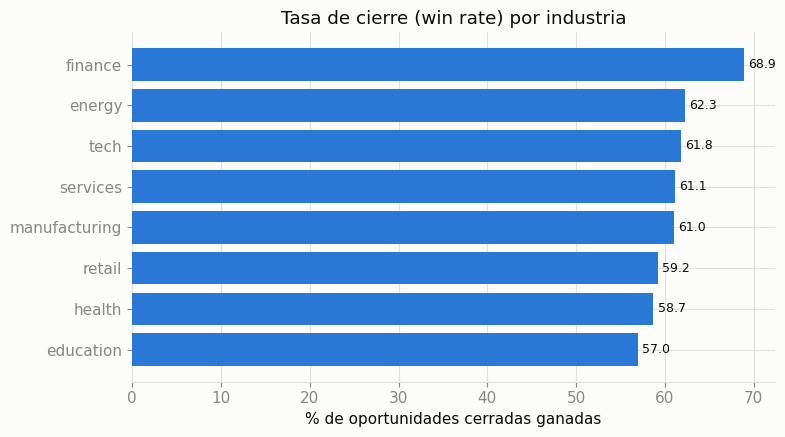

,industry,oportunidades_cerradas,ganadas,win_rate_pct
0,finance,90,62,68.9
1,energy,61,38,62.3
2,tech,144,89,61.8
3,services,72,44,61.1
4,manufacturing,82,50,61.0
5,retail,142,84,59.2
6,health,109,64,58.7
7,education,79,45,57.0


In [ ]:
winrate_ind = pd.read_sql("SELECT * FROM gold.vw_win_rate_by_industry ORDER BY win_rate_pct DESC", engine)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(winrate_ind["industry"], winrate_ind["win_rate_pct"], color=BLUE)
ax.invert_yaxis()
ax.set_xlabel("% de oportunidades cerradas ganadas")
ax.set_title("Tasa de cierre (win rate) por industria")
bar_labels(ax)
plt.tight_layout()
plt.show()
winrate_ind

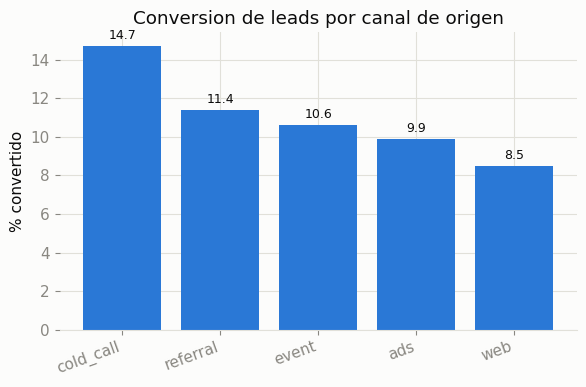

,source,leads,convertidos,conversion_rate_pct
0,cold_call,204,30,14.7
1,referral,402,46,11.4
2,event,302,32,10.6
3,ads,282,28,9.9
4,web,810,69,8.5


In [ ]:
conv_source = pd.read_sql("SELECT * FROM gold.vw_lead_conversion_by_source ORDER BY conversion_rate_pct DESC", engine)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(conv_source["source"], conv_source["conversion_rate_pct"], color=BLUE)
ax.set_ylabel("% convertido")
ax.set_title("Conversion de leads por canal de origen")
bar_labels(ax)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()
conv_source

**Hallazgo:** `finance` (68.9%) y `energy` (62.3%) tienen el win rate mas alto -- candidatos para priorizar esfuerzo comercial. `education` (57.0%) es el mas bajo, aunque la brecha entre industrias es de solo ~12 puntos -- ninguna industria es claramente mala.

En conversion de leads **si hay una brecha grande y accionable**: `cold_call` convierte al 14.7% vs. `web` al 8.5% -- casi el doble. Dado que `web` es el canal con mas volumen (810 leads vs. 204 de `cold_call`), mejorar la calificacion de leads web tiene mas impacto potencial en numero absoluto de conversiones que optimizar `cold_call`.

## 4. Cross-domain: estudiante vs. no-estudiante

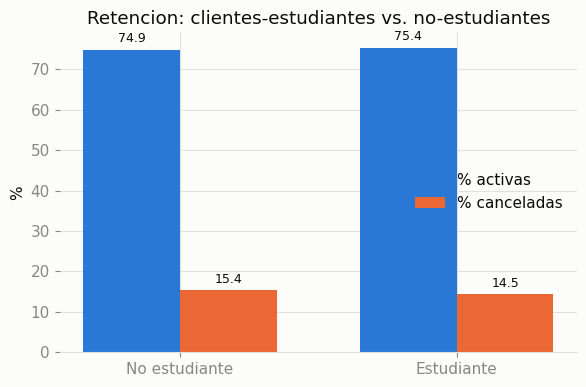

,is_student,suscripciones,pct_activas,pct_canceladas,grupo
0,False,7427,74.9,15.4,No estudiante
1,True,7573,75.4,14.5,Estudiante


In [ ]:
student_churn = pd.read_sql("SELECT * FROM gold.vw_retention_by_student_status", engine)
student_churn["grupo"] = student_churn["is_student"].map({True: "Estudiante", False: "No estudiante"})

x = range(len(student_churn))
fig, ax = plt.subplots(figsize=(6, 4))
w = 0.35
ax.bar([i - w/2 for i in x], student_churn["pct_activas"], width=w, label="% activas", color=BLUE)
ax.bar([i + w/2 for i in x], student_churn["pct_canceladas"], width=w, label="% canceladas", color=ORANGE)
ax.set_xticks(list(x))
ax.set_xticklabels(student_churn["grupo"])
ax.set_ylabel("%")
ax.set_title("Retencion: clientes-estudiantes vs. no-estudiantes")
ax.legend(frameon=False)
bar_labels(ax)
plt.tight_layout()
plt.show()
student_churn

**Hallazgo:** esta es la unica pregunta que cruza los 3 dominios con datos reales (via `dim_customer.student_id -> dim_student`, cobertura 50%). Los clientes-estudiantes cancelan menos (14.5%) que los no-estudiantes (15.4%) -- una diferencia real pero **pequena** (~1 punto). No es suficiente evidencia para justificar una estrategia de retencion completamente distinta segmentada por "es estudiante", pero si vale la pena monitorear si la brecha crece en corridas futuras.

## 5. Resumen ejecutivo
1. **Academico:** rendimiento parejo entre departamentos (~75/100, ~95% aprobacion). Desercion estable en ~10% en los 8 semestres -- sin tendencia de alerta, es un piso estructural, no un problema que empeora.
2. **Facturacion (churn):** `retail`/`smb` cancelan mas (15.0-15.2%) que `enterprise` (13.1%) -- diferencia moderada, consistente con lo esperado.
3. **Facturacion (cobranza):** el metodo de pago **no** afecta el tiempo de cobro (22.3-22.9 dias en los 4 metodos) -- se descarta esa hipotesis.
4. **Comercial (ventas):** `finance` y `energy` tienen el mejor win rate (63-69%); ninguna industria es mala (min. 57%).
5. **Comercial (marketing):** `cold_call` convierte casi el doble que `web` (14.7% vs 8.5%) -- pero `web` trae 4x mas volumen, asi que mejorar la calificacion de leads web es la palanca de mayor impacto absoluto.
6. **Cross-domain:** los clientes que ademas son estudiantes cancelan un poco menos (14.5% vs 15.4%) -- diferencia real pero pequena, a monitorear, no a actuar todavia.